### В данной домашней работе Вам предстоит отработать следующие 2 навыка: работа с пропущенными значениями и анализ выбросов.

In [1]:
import numpy as np
import pandas as pd

data = pd.read_csv('processed_data_with_new_features.csv', index_col='id')

In [2]:
data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,anomaly,traffic_jam,day_of_week_1,day_of_week_2,day_of_week_3,...,hour_19,hour_20,hour_21,hour_22,hour_23,month_2,month_3,month_4,month_5,month_6
id,,,,,,,,,,,,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
id2377394,0,930.399753,0,1.807119,6.498282,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
id3858529,1,NaN,0,6.392080,7.661527,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
id3504673,1,NaN,0,1.487155,6.063785,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
id2181028,1,930.399753,0,1.189925,6.077642,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


Никудышный гном случайно пролил кофе на папку с данными и кодом. К несчастью, из-за этого они с братьями потеряли кучу информации в столбиках **passenger_count** и **distance_km**.

In [3]:
### Выведите количество пропусков в данных колонках
### На всякий случай, проверьте целостность данных в остальных

# Количество пропусков в целом
print(data.isna().stack().value_counts())

# Количество пропусков в passenger_count
print(data['passenger_count'].isna().value_counts())

print(data['distance_km'].isna().value_counts())


False    59512676
True       291728
Name: count, dtype: int64
passenger_count
False    1312780
True      145864
Name: count, dtype: int64
distance_km
False    1312780
True      145864
Name: count, dtype: int64


Начнем с **passenger_count**. Вообще говоря, изначально это была категориальная колонка, к которой мы применили технику OneHotEncoder. Чтобы избавиться от пропусков в данных, конечно, можно просто убрать все объекты, в которых есть пропуски, но тогда мы потеряем ценную информацию. 

Воспользуйтесь относительно простым приемом из лекции: в указанной колонке заполните пропуски самым *популярным* значением среди неотсутствующих.

In [4]:
print(data['passenger_count'].value_counts(ascending=True).tail(1).index[0])

print(data['passenger_count'], data['passenger_count'].value_counts(dropna=False))

data['passenger_count'] = data['passenger_count'].fillna(data['passenger_count'].value_counts(ascending=True).tail(1).index[0])
print(data['passenger_count'], data['passenger_count'].value_counts(dropna=False))

930.3997532751514
id
id2875421    930.399753
id2377394    930.399753
id3858529           NaN
id3504673           NaN
id2181028    930.399753
                ...    
id2376096           NaN
id1049543    930.399753
id2304944    930.399753
id2714485    930.399753
id1209952           NaN
Name: passenger_count, Length: 1458644, dtype: float64 passenger_count
930.399753     930354
1005.458335    189262
NaN            145864
1070.232174     70348
1028.236276     53751
1061.355223     43460
1053.529749     25543
1718.433333        57
19.666667           3
560.000000          1
104.000000          1
Name: count, dtype: int64
id
id2875421    930.399753
id2377394    930.399753
id3858529    930.399753
id3504673    930.399753
id2181028    930.399753
                ...    
id2376096    930.399753
id1049543    930.399753
id2304944    930.399753
id2714485    930.399753
id1209952    930.399753
Name: passenger_count, Length: 1458644, dtype: float64 passenger_count
930.399753     1076218
1005.458335    

С колонкой **distance_km** поступим более интересным способом!

Чтобы заполнить пропуск в данной колонке для того или иного объекта, можно находить наиболее похожий на него объект и подглядывать в его значение **distance_km**. Для того, чтобы понять, насколько объекты похожи друг на друга, необходимо использовать Евклидово расстояние между этими самыми объектами в пространстве всех признаков!

С учетом количества объектов в нашем датасете и признаков, посчитать попарные расстояния будет мега-сложно. Поэтому давайте называть объекты похожими, если они принадлежат одной категории, составленной из следующих колонок:

1. vendor_id
2. store_and_fwd_flag
3. traffic_jam
4. month_2
5. month_3
6. month_4
7. month_5
8. month_6

Внутри каждой группы найдите среднее значение признака **distance_km** и заполните NaN'ы в объектах с пропуском в соответствии с тем, к какой категории относится данный объект. Похожее упражнение мы делали на практике в занятии!

**Hint**: достаточно просто взять group by по указанным выше категориальным колонкам и верно вставить полученный результат в исходную табличку.

P.S. Колонки выбраны случайным образом. Можно было взять и другую комбинацию.

In [5]:
s = data.groupby(['vendor_id', 'store_and_fwd_flag', 'traffic_jam', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6'])['distance_km'].transform('mean')
print(s)
data['distance_km'] = data['distance_km'].fillna(s)

id
id2875421    3.466395
id2377394    3.463570
id3858529    3.183494
id3504673    3.468311
id2181028    3.466395
               ...   
id2376096    3.468311
id1049543    3.323767
id2304944    3.468311
id2714485    3.323767
id1209952    3.389926
Name: distance_km, Length: 1458644, dtype: float64


In [6]:
### Убедимся, что пропусков не осталось

print(data['distance_km'].isna().value_counts())

data.head(20).to_csv('output.csv', index=False, sep=';')

distance_km
False    1458644
Name: count, dtype: int64


### Теперь наши данные чисты! Замерьте качество модели на Кросс-Валидации

In [7]:
from sklearn.model_selection import KFold

selector = KFold(n_splits=4, shuffle=True, random_state=33)

from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression

model = LinearRegression()
cross_val_error = cross_validate(model, data.drop('log_trip_duration', axis=1), data['log_trip_duration'], scoring='neg_mean_squared_error', cv=selector)['test_score'].mean()

print(f"MSLE на Кросс-валидации: {-round(cross_val_error, 3)}")

MSLE на Кросс-валидации: 0.431


### Проведем анализ выбросов! Нарисуйте ящик с усами и гистограмму для таргетной переменной.

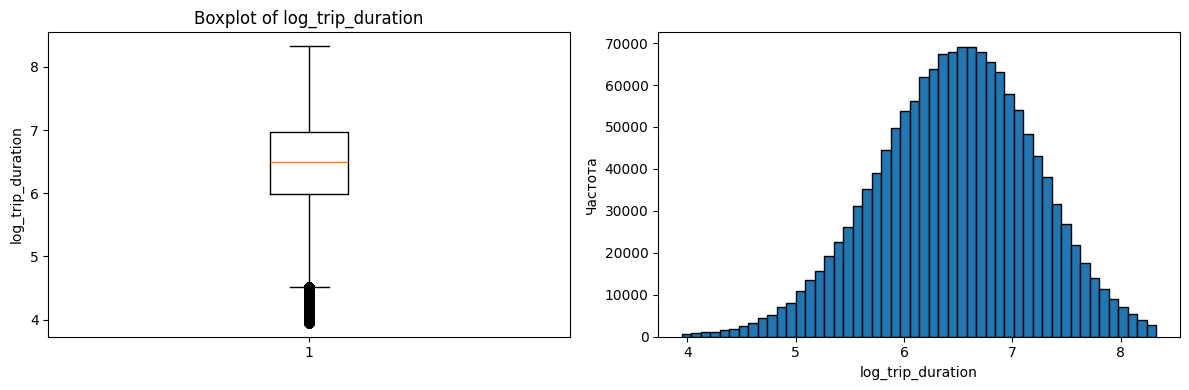

In [13]:
import matplotlib.pyplot as plt

# Ящик с усами для таргета
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.boxplot(data['log_trip_duration'].dropna())  # убираем NaN на всякий случай
plt.title('Boxplot of log_trip_duration')
plt.ylabel('log_trip_duration')


# Гистограмма для таргета
plt.subplot(1, 2, 2)
plt.hist(data['log_trip_duration'].dropna(), bins=50, edgecolor='black')
plt.ylabel('Частота')
plt.xlabel('log_trip_duration')

plt.tight_layout()
plt.show()

Есть ли, на ваш взгляд, в данных выбросы?

Кажется, что да!

Давайте почистим их, удалив те объекты, таргеты которых находятся вне промежутка

(топ 99,5% значение;   топ 0,5% значение)

In [9]:
data = data[(data['log_trip_duration'] < data['log_trip_duration'].quantile(0.995)) & (data['log_trip_duration'] > data['log_trip_duration'].quantile(0.005))]

print(data['log_trip_duration'].quantile(0.995), data['log_trip_duration'].quantile(0.005))

8.144679183447758 4.477336814478207


Снова замерьте качество на кросс-валидации, используя старый selector

In [10]:
model = LinearRegression()
cross_val_error = cross_validate(model, data.drop('log_trip_duration', axis=1), data['log_trip_duration'], scoring='neg_mean_squared_error', cv=selector)['test_score'].mean()

print(f"MSLE на Кросс-валидации: {-round(cross_val_error, 3)}")

MSLE на Кросс-валидации: 0.35
